# 🎭 Face Mask Detection — Evaluator
**Role 5 — Doha**  
Confusion Matrix | Per-Class Metrics | Misclassification Analysis

## ⚙️ Step 1 — Imports & Config

In [8]:
import os
import sys
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, models, transforms

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve
)

# ── Paths ────────────────────────────────────────────────────────────────────
# notebooks/ is the cwd when running this notebook
BASE_DIR    = os.path.abspath(os.path.join(os.getcwd(), ".."))  # face-mask-AML_project/
DATA_DIR    = os.path.join(BASE_DIR, "data")                    # face-mask-AML_project/data/
MODEL_PATH  = os.path.join(BASE_DIR, "model", "mask_detector.pth")
REPORTS_DIR = os.path.join(BASE_DIR, "reports")
os.makedirs(REPORTS_DIR, exist_ok=True)

BATCH_SIZE = 32
DEVICE     = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print(f'Device     : {DEVICE}')
print(f'Data dir   : {DATA_DIR}')
print(f'Model path : {MODEL_PATH}')
print(f'Reports    : {REPORTS_DIR}')

Device     : cpu
Data dir   : c:\Users\dohah\Documents\programming\Projects\face-mask-AML_project\data
Model path : c:\Users\dohah\Documents\programming\Projects\face-mask-AML_project\model\mask_detector.pth
Reports    : c:\Users\dohah\Documents\programming\Projects\face-mask-AML_project\reports


## 🔄 Step 2 — Load Test Data

In [9]:
# Same normalization used in training — no augmentation on test set
test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

test_dataset = datasets.ImageFolder(
    root=os.path.join(DATA_DIR, 'Test'),
    transform=test_transform
)

test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

CLASSES = test_dataset.classes
print('Classes:', CLASSES)
print(f'Total test images: {len(test_dataset)}')

Classes: ['WithMask', 'WithoutMask']
Total test images: 988


## 🤖 Step 3 — Load Trained Model

In [10]:
def load_model(model_path, num_classes=2):
    model = models.mobilenet_v2(weights=None)
    # Must match Ghada's classifier exactly:
    # classifier.1 → Linear(1280, 256)
    # classifier.4 → Linear(256, 2)
    model.classifier = nn.Sequential(
        nn.Dropout(0.2),
        nn.Linear(model.last_channel, 256),
        nn.ReLU(),
        nn.Dropout(0.2),
        nn.Linear(256, num_classes)
    )
    checkpoint = torch.load(model_path, map_location=DEVICE, weights_only=False)
    if isinstance(checkpoint, dict) and 'model_state_dict' in checkpoint:
        state_dict = checkpoint['model_state_dict']
    else:
        state_dict = checkpoint
    model.load_state_dict(state_dict)
    model.to(DEVICE)
    model.eval()
    return model

model = load_model(MODEL_PATH)
print('✅ Model loaded!')

✅ Model loaded!


## 🔍 Step 4 — Run Inference on Test Set

In [11]:
all_preds  = []
all_labels = []
all_probs  = []
all_paths  = [s[0] for s in test_dataset.samples]

with torch.no_grad():
    for batch_idx, (images, labels) in enumerate(test_loader):
        images  = images.to(DEVICE)
        outputs = model(images)
        probs   = torch.softmax(outputs, dim=1).cpu().numpy()
        preds   = probs.argmax(axis=1)

        all_probs.extend(probs)
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())

all_preds      = np.array(all_preds)
all_labels     = np.array(all_labels)
all_probs      = np.array(all_probs)
max_confidence = all_probs.max(axis=1)

print(f'✅ Inference done on {len(all_labels)} images')

✅ Inference done on 988 images


## 📊 Step 5 — Overall Metrics

In [12]:
accuracy  = accuracy_score(all_labels, all_preds)
precision = precision_score(all_labels, all_preds, average='weighted')
recall    = recall_score(all_labels, all_preds, average='weighted')
f1        = f1_score(all_labels, all_preds, average='weighted')
auc       = roc_auc_score(all_labels, all_probs[:, 1])

print('=' * 45)
print('       OVERALL EVALUATION METRICS')
print('=' * 45)
print(f'  Accuracy  : {accuracy:.4f}  ({accuracy*100:.2f}%)')
print(f'  Precision : {precision:.4f}')
print(f'  Recall    : {recall:.4f}')
print(f'  F1-Score  : {f1:.4f}')
print(f'  ROC-AUC   : {auc:.4f}')
print('=' * 45)
print(f'  Target (>90%): {"✅ MET" if accuracy >= 0.90 else "⚠️  Below target"}')

       OVERALL EVALUATION METRICS
  Accuracy  : 0.9990  (99.90%)
  Precision : 0.9990
  Recall    : 0.9990
  F1-Score  : 0.9990
  ROC-AUC   : 1.0000
  Target (>90%): ✅ MET


## 🗂️ Step 6 — Per-Class Metrics

In [13]:
print(classification_report(all_labels, all_preds, target_names=CLASSES, digits=4))

              precision    recall  f1-score   support

    WithMask     0.9979    1.0000    0.9990       482
 WithoutMask     1.0000    0.9980    0.9990       506

    accuracy                         0.9990       988
   macro avg     0.9990    0.9990    0.9990       988
weighted avg     0.9990    0.9990    0.9990       988



## 🟦 Step 7 — Confusion Matrix

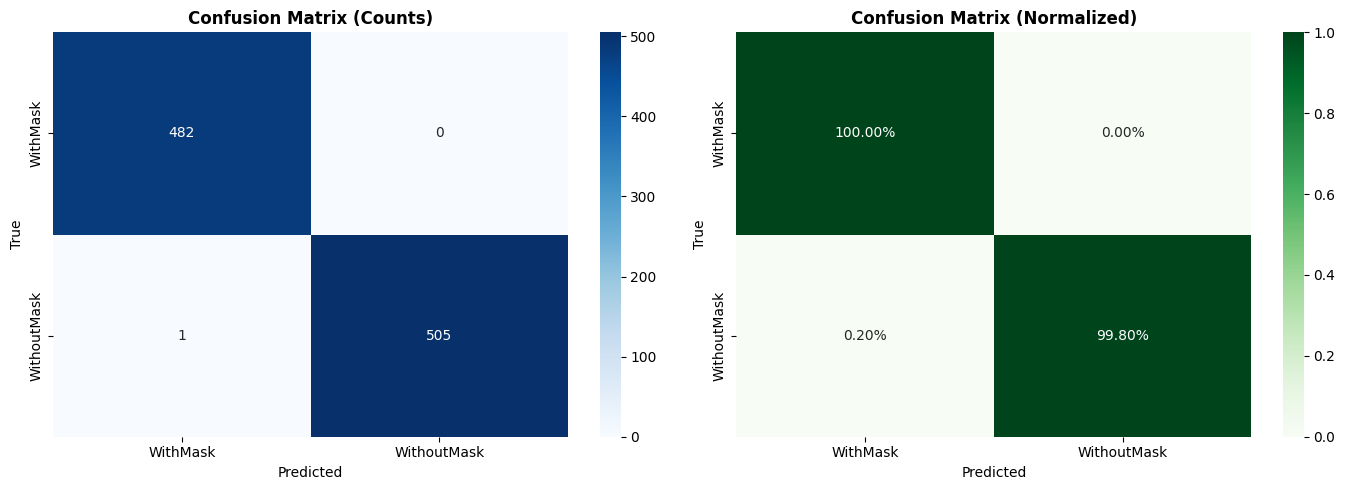

In [14]:
cm      = confusion_matrix(all_labels, all_preds)
cm_norm = cm.astype('float') / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASSES, yticklabels=CLASSES, ax=axes[0])
axes[0].set_title('Confusion Matrix (Counts)', fontweight='bold')
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('True')

sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='Greens',
            xticklabels=CLASSES, yticklabels=CLASSES, ax=axes[1])
axes[1].set_title('Confusion Matrix (Normalized)', fontweight='bold')
axes[1].set_xlabel('Predicted'); axes[1].set_ylabel('True')

plt.tight_layout()
plt.savefig(os.path.join(REPORTS_DIR, 'confusion_matrix.png'), dpi=150, bbox_inches='tight')
plt.show()

## 📈 Step 8 — ROC Curve

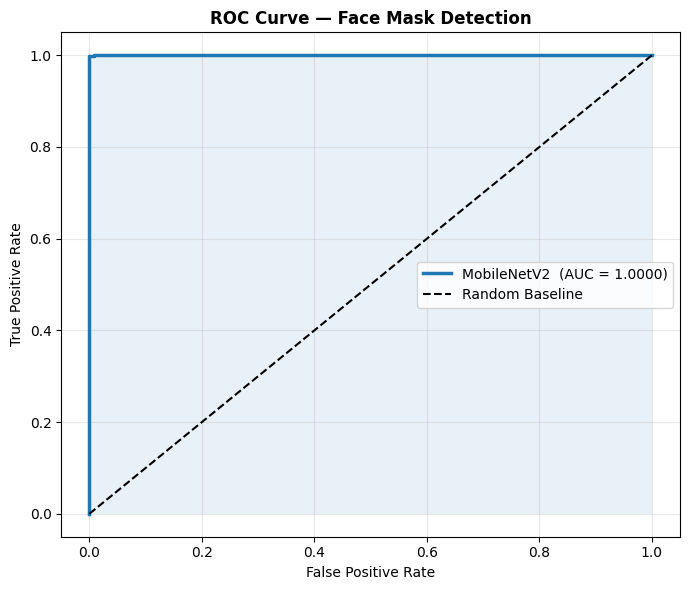

In [15]:
fpr, tpr, _ = roc_curve(all_labels, all_probs[:, 1])

plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, lw=2.5, label=f'MobileNetV2  (AUC = {auc:.4f})')
plt.plot([0, 1], [0, 1], 'k--', lw=1.5, label='Random Baseline')
plt.fill_between(fpr, tpr, alpha=0.1)
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
plt.title('ROC Curve — Face Mask Detection', fontweight='bold')
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout()
plt.savefig(os.path.join(REPORTS_DIR, 'roc_curve.png'), dpi=150, bbox_inches='tight')
plt.show()

## 📊 Step 9 — Per-Class Metrics Bar Chart

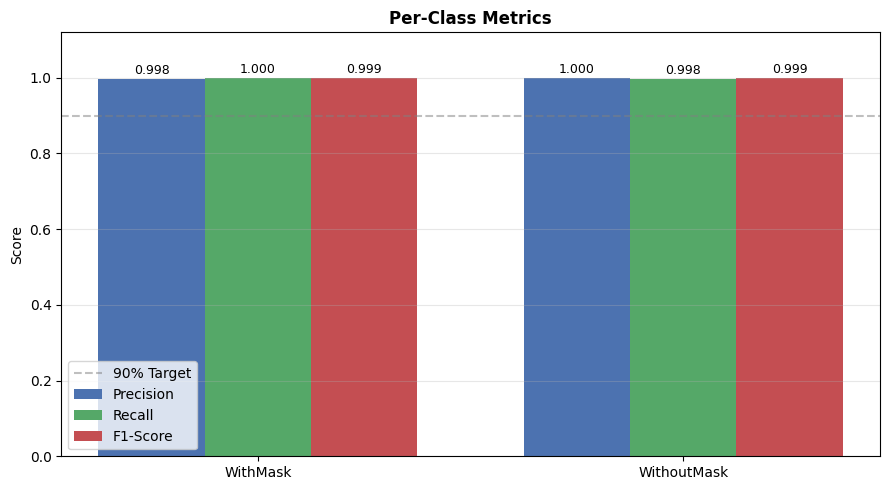

In [16]:
prec_per_class = precision_score(all_labels, all_preds, average=None)
rec_per_class  = recall_score(all_labels, all_preds, average=None)
f1_per_class   = f1_score(all_labels, all_preds, average=None)

x, w = np.arange(len(CLASSES)), 0.25
fig, ax = plt.subplots(figsize=(9, 5))

b1 = ax.bar(x - w, prec_per_class, w, label='Precision', color='#4C72B0')
b2 = ax.bar(x,     rec_per_class,  w, label='Recall',    color='#55A868')
b3 = ax.bar(x + w, f1_per_class,   w, label='F1-Score',  color='#C44E52')

for bars in [b1, b2, b3]:
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.005,
                f'{h:.3f}', ha='center', va='bottom', fontsize=9)

ax.set_xticks(x); ax.set_xticklabels(CLASSES)
ax.set_ylim(0, 1.12); ax.set_ylabel('Score')
ax.set_title('Per-Class Metrics', fontweight='bold')
ax.axhline(0.9, color='gray', linestyle='--', alpha=0.5, label='90% Target')
ax.legend(); ax.grid(axis='y', alpha=0.3); plt.tight_layout()
plt.savefig(os.path.join(REPORTS_DIR, 'per_class_metrics.png'), dpi=150, bbox_inches='tight')
plt.show()

## 🔬 Step 10 — Confidence Distribution

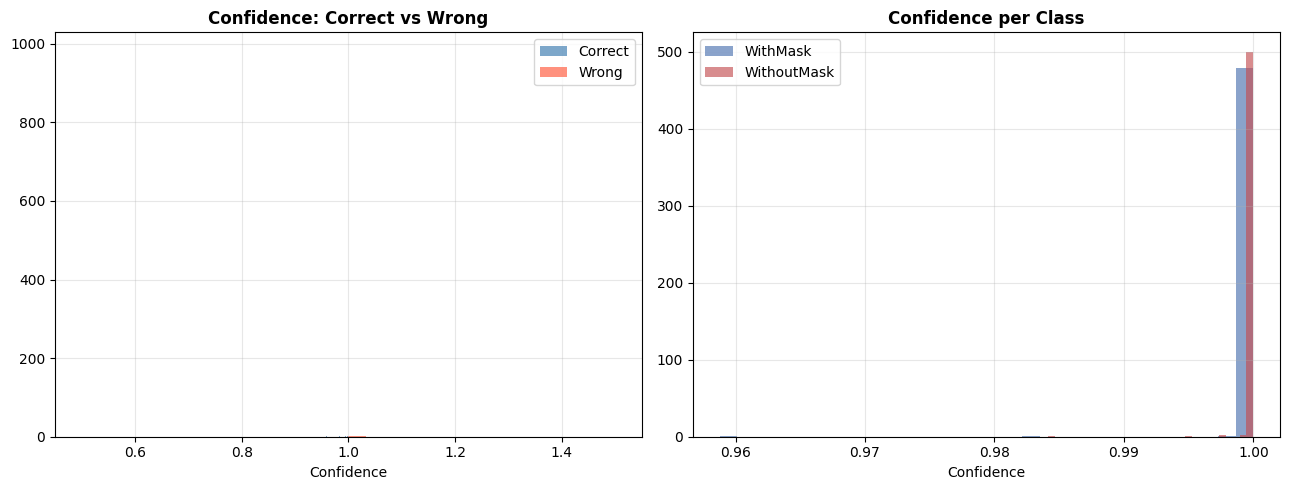

In [17]:
correct_mask = (all_preds == all_labels)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].hist(max_confidence[correct_mask],  bins=30, alpha=0.7, color='steelblue', label='Correct')
axes[0].hist(max_confidence[~correct_mask], bins=30, alpha=0.7, color='tomato',    label='Wrong')
axes[0].set_title('Confidence: Correct vs Wrong', fontweight='bold')
axes[0].set_xlabel('Confidence'); axes[0].legend(); axes[0].grid(alpha=0.3)

for i, (cls, color) in enumerate(zip(CLASSES, ['#4C72B0', '#C44E52'])):
    axes[1].hist(max_confidence[all_labels == i], bins=30, alpha=0.65, color=color, label=cls)
axes[1].set_title('Confidence per Class', fontweight='bold')
axes[1].set_xlabel('Confidence'); axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(REPORTS_DIR, 'confidence_distribution.png'), dpi=150, bbox_inches='tight')
plt.show()

## ❌ Step 11 — Misclassified Images

In [18]:
wrong_indices = np.where(all_preds != all_labels)[0]
print(f'Misclassified: {len(wrong_indices)} / {len(all_labels)}  ({len(wrong_indices)/len(all_labels)*100:.2f}%)')

for true_cls in range(len(CLASSES)):
    for pred_cls in range(len(CLASSES)):
        if true_cls == pred_cls: continue
        count = np.sum((all_labels == true_cls) & (all_preds == pred_cls))
        if count > 0:
            print(f'  {CLASSES[true_cls]} → predicted as {CLASSES[pred_cls]}: {count} images')

Misclassified: 1 / 988  (0.10%)
  WithoutMask → predicted as WithMask: 1 images


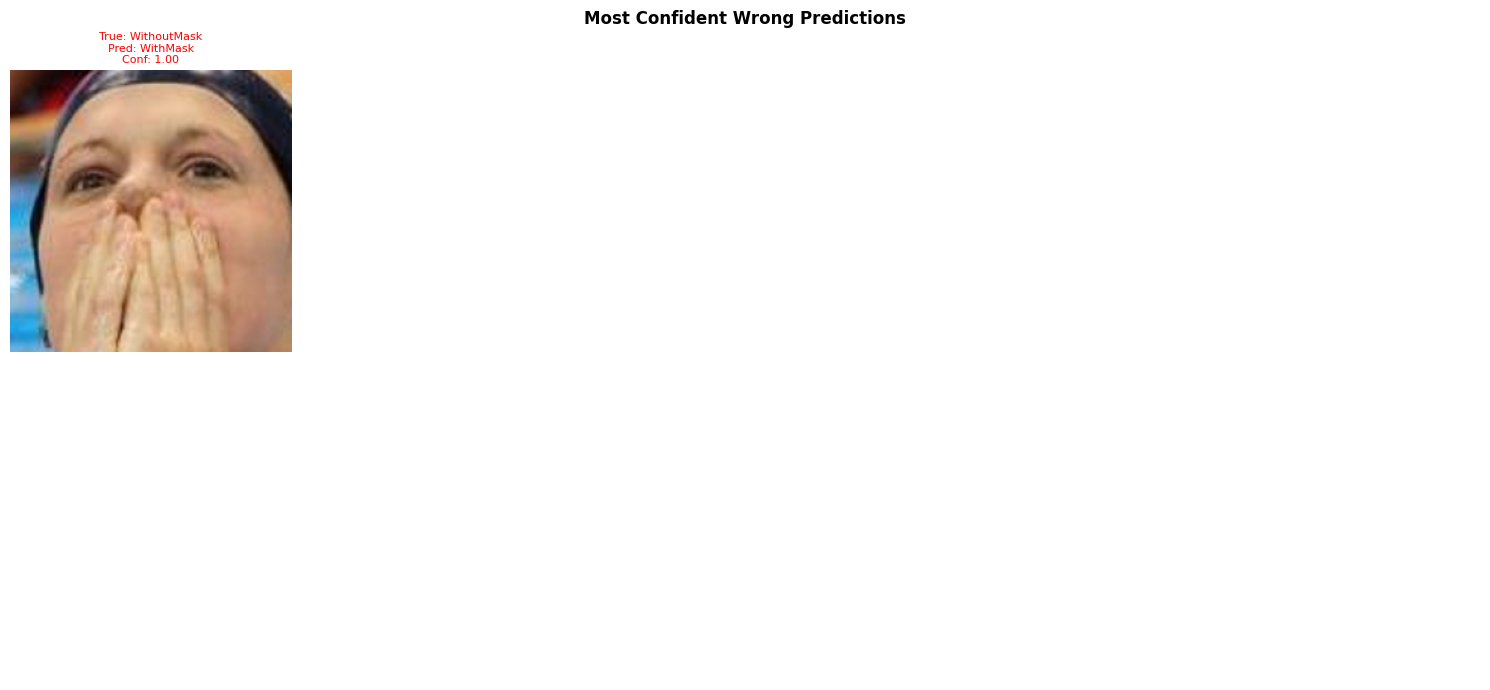

In [19]:
if len(wrong_indices) > 0:
    sorted_idx = wrong_indices[np.argsort(max_confidence[wrong_indices])[::-1]]
    n_show = min(10, len(sorted_idx))

    fig, axes = plt.subplots(2, 5, figsize=(15, 7))
    for i, ax in enumerate(axes.flat):
        if i >= n_show:
            ax.axis('off')
            continue
        idx = sorted_idx[i]
        img = Image.open(all_paths[idx]).convert('RGB').resize((224, 224))
        ax.imshow(img)
        ax.set_title(
            f'True: {CLASSES[all_labels[idx]]}\nPred: {CLASSES[all_preds[idx]]}\nConf: {max_confidence[idx]:.2f}',
            fontsize=8, color='red'
        )
        ax.axis('off')

    plt.suptitle('Most Confident Wrong Predictions', fontweight='bold')
    plt.tight_layout()
    plt.savefig(os.path.join(REPORTS_DIR, 'misclassified_samples.png'), dpi=150, bbox_inches='tight')
    plt.show()

## 🎯 Step 12 — Threshold Analysis

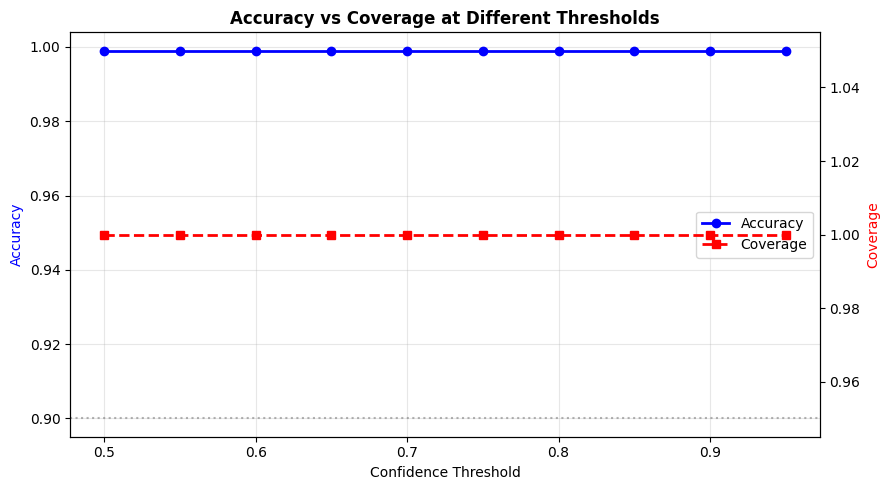

In [20]:
thresholds_list = np.arange(0.5, 1.0, 0.05)
coverages, accuracies = [], []

for t in thresholds_list:
    mask = max_confidence >= t
    coverages.append(mask.sum() / len(all_labels))
    accuracies.append(accuracy_score(all_labels[mask], all_preds[mask]) if mask.sum() > 0 else 0)

fig, ax1 = plt.subplots(figsize=(9, 5))
ax2 = ax1.twinx()
ax1.plot(thresholds_list, accuracies, 'b-o', lw=2, label='Accuracy')
ax2.plot(thresholds_list, coverages,  'r--s', lw=2, label='Coverage')
ax1.axhline(0.9, color='gray', linestyle=':', alpha=0.6)
ax1.set_xlabel('Confidence Threshold')
ax1.set_ylabel('Accuracy', color='blue')
ax2.set_ylabel('Coverage', color='red')
ax1.set_title('Accuracy vs Coverage at Different Thresholds', fontweight='bold')
lines  = ax1.get_legend_handles_labels()[0] + ax2.get_legend_handles_labels()[0]
labels = ax1.get_legend_handles_labels()[1] + ax2.get_legend_handles_labels()[1]
ax1.legend(lines, labels); ax1.grid(alpha=0.3); plt.tight_layout()
plt.savefig(os.path.join(REPORTS_DIR, 'threshold_analysis.png'), dpi=150, bbox_inches='tight')
plt.show()

## 📝 Step 13 — Final Summary

In [21]:
print('=' * 55)
print('    FACE MASK DETECTION — FINAL REPORT')
print('    Role 5: Evaluator — Doha')
print('=' * 55)
print(f'  Model       : MobileNetV2 (Transfer Learning)')
print(f'  Test Images : {len(all_labels)}')
print(f'  Classes     : {CLASSES}')
print()
print(f'  Accuracy  : {accuracy:.4f}  ({accuracy*100:.2f}%)')
print(f'  Precision : {precision:.4f}')
print(f'  Recall    : {recall:.4f}')
print(f'  F1-Score  : {f1:.4f}')
print(f'  ROC-AUC   : {auc:.4f}')
print()
print(f'  Target (>90%): {"✅ MET" if accuracy >= 0.90 else "⚠️  NOT MET"}')
print()
print(f'  Plots saved to: {REPORTS_DIR}')
print('=' * 55)

    FACE MASK DETECTION — FINAL REPORT
    Role 5: Evaluator — Doha
  Model       : MobileNetV2 (Transfer Learning)
  Test Images : 988
  Classes     : ['WithMask', 'WithoutMask']

  Accuracy  : 0.9990  (99.90%)
  Precision : 0.9990
  Recall    : 0.9990
  F1-Score  : 0.9990
  ROC-AUC   : 1.0000

  Target (>90%): ✅ MET

  Plots saved to: c:\Users\dohah\Documents\programming\Projects\face-mask-AML_project\reports
